In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import shap

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score

from xgboost import XGBRegressor

ROOT = Path.cwd().parent
print(ROOT)

DATA_RAW = ROOT/"data/raw"
DATA_PROCESSED = ROOT/"data/processed"

c:\Users\sebas\PycharmProjects\Git\BoxOffice_Oracle


In [2]:
model_df = pd.read_csv(
    DATA_RAW/"fe_groups/g1.csv"
)

print(model_df.shape)
model_df.head()

(2255, 57)


,Unnamed: 0.1,Unnamed: 0,tconst,primaryTitle,startYear,the_numbers_url,scrape_success,scrape_error,opening_weekend_gross,opening_theaters,...,actor_3_name,g1_prior_same_genre_director_count,g1_prior_same_genre_writer_count,g1_prior_same_genre_actor_1_count,g1_prior_same_genre_actor_2_count,g1_prior_same_genre_actor_3_count,g1_prior_same_genre_distributor_count,g1_prior_same_genre_top3_actor_total,g1_prior_same_genre_top3_actor_max,g1_prior_same_genre_top3_actor_mean
0,0,1112,tt1311067,Halloween II,2009.0,https://www.the-numbers.com/movie/Halloween-II,True,NaN,7676836.0,1217.0,...,Malcolm McDowell,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,689,tt0816462,Conan the Barbarian,2011.0,https://www.the-numbers.com/movie/Conan-the-Ba...,True,NaN,9479373.0,1358.0,...,Rose McGowan,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,1974,tt4731008,The Wild Life,2016.0,https://www.the-numbers.com/movie/Wild-Life-The,True,NaN,4001400.0,1140.0,...,Ilka Bessin,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,980,tt1160419,Dune: Part One,2021.0,https://www.the-numbers.com/movie/Dune,True,NaN,6025091.0,915.0,...,Zendaya,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,4,1291,tt1540128,Playing for Keeps,2012.0,https://www.the-numbers.com/movie/Playing-for-...,True,NaN,1406300.0,1148.0,...,Dennis Quaid,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
target = "log_opening_weekend_gross"

g1_features = [
    'g1_prior_same_genre_director_count',
    'g1_prior_same_genre_writer_count',
    'g1_prior_same_genre_actor_1_count',
    'g1_prior_same_genre_actor_2_count',
    'g1_prior_same_genre_actor_3_count',
    'g1_prior_same_genre_distributor_count',
    'g1_prior_same_genre_top3_actor_total',
    'g1_prior_same_genre_top3_actor_max',
    'g1_prior_same_genre_top3_actor_mean'
]

numeric_features = [
    # "opening_theaters",
    "production_budget",
    "runtime_minutes",
    "release_month",
    "release_day_of_year",
] + g1_features

people_features = [
    "director_id",
    "writer_id",
    "actor_1",
    "actor_2",
    "actor_3",
]

categorical_features = [
    # "release_type",
    "distributor",
    "MPA_rating",
    "genre",
    "subgenre",
    "source",
    "production_method",
    "creative_type",
    "production_countries",
    "languages",
] + people_features

In [4]:
for col in people_features:

    counts = model_df[col].value_counts(dropna=False)

    other_count = (model_df[col] == "OTHER").sum()

    print("\n" + "=" * 50)
    print(col)

    print(f"Unique values: {model_df[col].nunique(dropna=False)}")
    print(f"OTHER count: {other_count}")
    print(f"OTHER %: {other_count / len(model_df):.3f}")

    print("\nTop values:")
    print(counts.head(10))


director_id
Unique values: 1108
OTHER count: 0
OTHER %: 0.000

Top values:
director_id
nm0000142    15
nm0000631    15
nm0000229    13
nm0000095    12
nm1347153    11
nm0000318    10
nm0298807     9
nm1490123     9
nm0000165     9
nm0634240     9
Name: count, dtype: int64

writer_id
Unique values: 1435
OTHER count: 0
OTHER %: 0.000

Top values:
writer_id
NaN          13
nm1347153    12
nm0000095    12
nm1191481     9
nm0921013     9
nm0472567     8
nm0604555     8
nm0934483     7
nm0027271     7
nm0027572     7
Name: count, dtype: int64

actor_1
Unique values: 939
OTHER count: 0
OTHER %: 0.000

Top values:
actor_1
nm0425005    22
nm0001191    20
nm0002071    19
nm0000136    18
nm0000243    18
nm0000242    18
nm0000158    17
nm0136797    17
nm0000354    16
nm0000129    16
Name: count, dtype: int64

actor_2
Unique values: 1286
OTHER count: 0
OTHER %: 0.000

Top values:
actor_2
NaN          24
nm0000168    13
nm0004937    10
nm0000949    10
nm0005562     9
nm0933940     9
nm1046097     9

In [6]:
feature_cols = numeric_features + categorical_features

model_data = model_df[
    feature_cols + [target, "opening_weekend_gross"]
].copy()

X = model_data[feature_cols]
y = model_data[target]

print(X.shape)
print(y.shape)

(2255, 27)
(2255,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
y_test_dollars = np.expm1(y_test)

In [9]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [10]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    pred_log = model.predict(X_test)

    r2_log = r2_score(y_test, pred_log)
    mae_log = mean_absolute_error(y_test, pred_log)

    pred_dollars = np.expm1(pred_log)

    mae_dollars = mean_absolute_error(y_test_dollars, pred_dollars)

    results = {
        "model": name,
        "r2_log": r2_log,
        "mae_log": mae_log,
        "mae_dollars": mae_dollars
    }

    return results, pred_log, pred_dollars

In [11]:
ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_results, ridge_pred_log, ridge_pred_dollars = evaluate_model(
    "Ridge Baseline",
    ridge_model,
    X_train,
    X_test,
    y_train,
    y_test
)

ridge_results

{'model': 'Ridge Baseline',
 'r2_log': 0.5917871306820597,
 'mae_log': 0.8014671022735447,
 'mae_dollars': 15157480.853755657}

In [12]:
xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    ))
])

xgb_results, xgb_pred_log, xgb_pred_dollars = evaluate_model(
    "XGBoost Baseline",
    xgb_model,
    X_train,
    X_test,
    y_train,
    y_test
)

xgb_results

{'model': 'XGBoost Baseline',
 'r2_log': 0.6311835761003037,
 'mae_log': 0.7427312634099654,
 'mae_dollars': 12045563.681307161}

In [13]:
results_df = pd.DataFrame([
    ridge_results,
    xgb_results
])

results_df

,model,r2_log,mae_log,mae_dollars
0,Ridge Baseline,0.591787,0.801467,1.515748e+07
1,XGBoost Baseline,0.631184,0.742731,1.204556e+07


In [14]:
plot_df = pd.DataFrame({
    "actual": y_test_dollars,
    "predicted": xgb_pred_dollars
})

fig = px.scatter(
    plot_df,
    x="actual",
    y="predicted",
    title="XGBoost Baseline: Actual vs Predicted",
    opacity=0.6
)

fig.add_shape(
    type="line",
    x0=plot_df["actual"].min(),
    y0=plot_df["actual"].min(),
    x1=plot_df["actual"].max(),
    y1=plot_df["actual"].max(),
)

fig.show()

In [15]:
X_train_transformed = (
    xgb_model.named_steps["preprocessor"]
    .transform(X_train)
)

X_test_transformed = (
    xgb_model.named_steps["preprocessor"]
    .transform(X_test)
)

feature_names = (
    xgb_model.named_steps["preprocessor"]
    .get_feature_names_out()
)

trained_xgb = xgb_model.named_steps["model"]

In [16]:
explainer = shap.TreeExplainer(trained_xgb)

X_shap = X_test_transformed[:500]

shap_values = explainer.shap_values(X_shap)

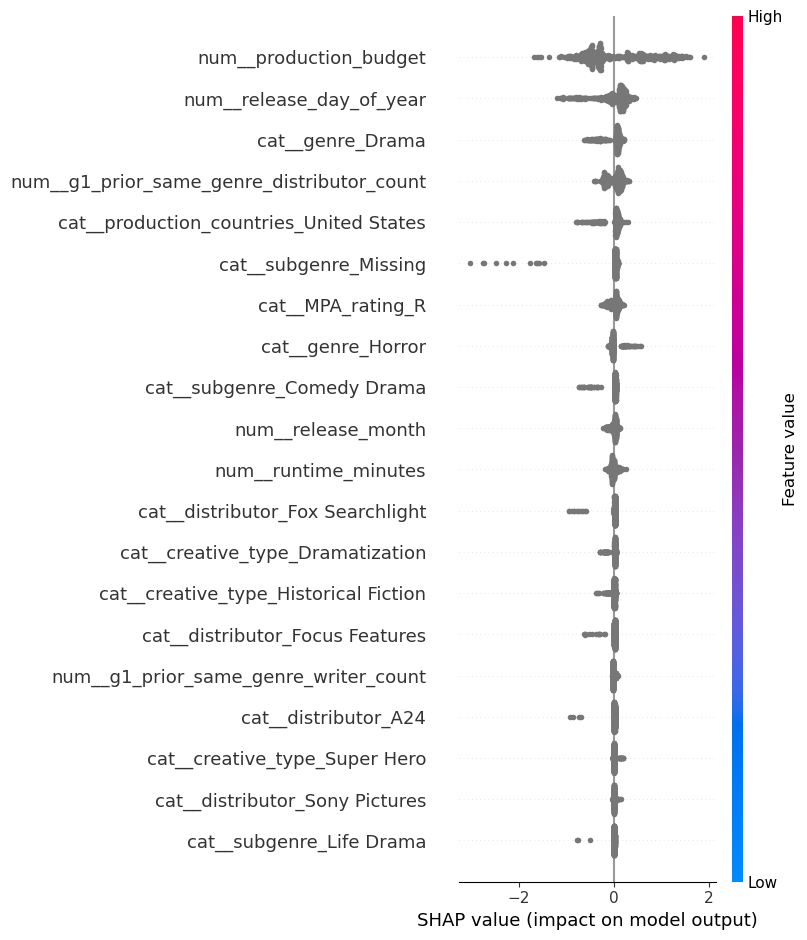

In [17]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names
)

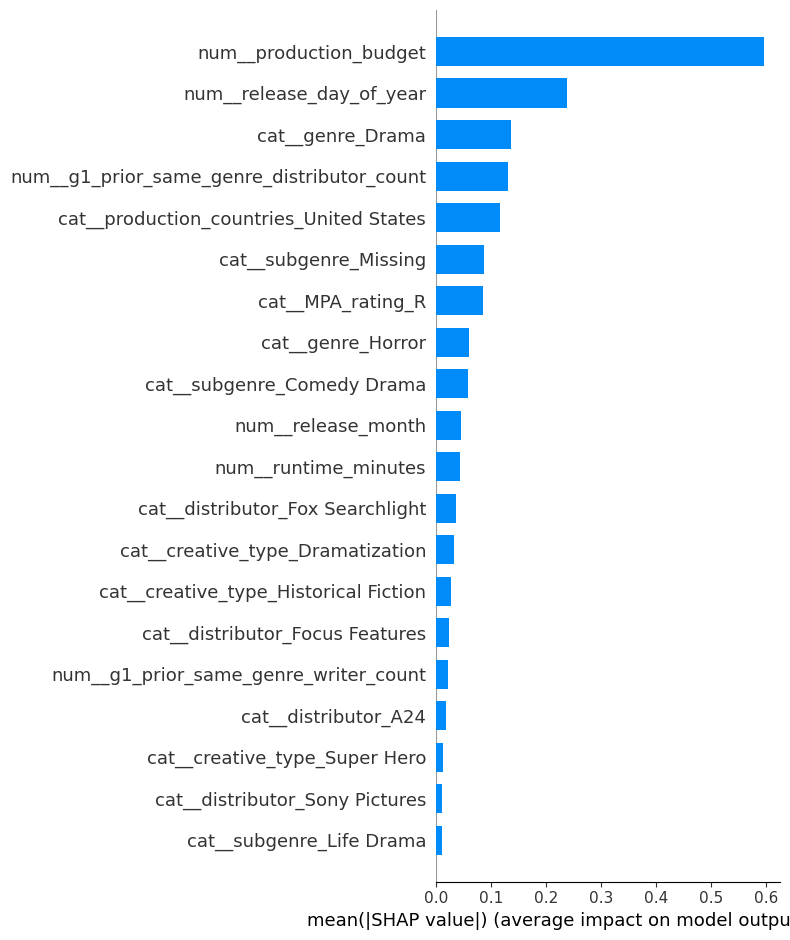

In [18]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    plot_type="bar"
)

In [19]:
error_df = X_test.copy()

error_df["actual_log"] = y_test
error_df["pred_log"] = xgb_pred_log

error_df["actual_opening_weekend"] = np.expm1(y_test)
error_df["pred_opening_weekend"] = xgb_pred_dollars

error_df["abs_error"] = (
    error_df["actual_opening_weekend"] -
    error_df["pred_opening_weekend"]
).abs()

error_df.sort_values("abs_error", ascending=False).head(20)

,production_budget,runtime_minutes,release_month,release_day_of_year,g1_prior_same_genre_director_count,g1_prior_same_genre_writer_count,g1_prior_same_genre_actor_1_count,g1_prior_same_genre_actor_2_count,g1_prior_same_genre_actor_3_count,g1_prior_same_genre_distributor_count,...,director_id,writer_id,actor_1,actor_2,actor_3,actual_log,pred_log,actual_opening_weekend,pred_opening_weekend,abs_error
1847,400000000.0,181.0,4,116,2.0,4.0,5.0,2.0,1.0,19.0,...,nm0751577,nm1321655,nm0000375,nm0262635,nm0749263,19.693568,18.777588,3.571150e+08,142890320.0,2.142247e+08
1718,200000000.0,120.0,2,47,0.0,0.0,0.0,0.0,0.0,16.0,...,nm3363032,nm3363032,nm1569276,nm0430107,nm2143282,19.123798,18.111956,2.020040e+08,73438264.0,1.285657e+08
1907,150000000.0,103.0,11,326,1.0,1.0,1.0,1.0,0.0,9.0,...,nm0118333,nm1601644,nm0068338,nm0579953,nm1265802,18.685069,15.062202,1.302634e+08,3478814.5,1.267845e+08
1619,160000000.0,123.0,3,76,0.0,0.0,0.0,0.0,0.0,4.0,...,NaN,NaN,nm5177626,nm11380870,nm3592451,18.978870,17.711571,1.747506e+08,49208196.0,1.255424e+08
2126,145000000.0,114.0,7,202,0.0,0.0,0.0,0.0,0.0,53.0,...,nm1950086,nm1950086,nm3053338,nm0331516,nm4793987,18.903243,17.437086,1.620220e+08,37396440.0,1.246256e+08
1620,160000000.0,123.0,3,76,1.0,0.0,0.0,0.0,0.0,5.0,...,nm0174374,nm0154716,nm0914612,nm1405398,nm1812656,18.978870,17.757664,1.747506e+08,51529432.0,1.232212e+08
1753,200000000.0,118.0,6,166,3.0,2.0,1.0,0.0,0.0,68.0,...,nm0083348,nm0083348,nm0005266,nm0000456,nm1102970,19.023290,18.174908,1.826879e+08,78209968.0,1.044779e+08
2204,200000000.0,100.0,6,166,0.0,1.0,1.0,0.0,0.0,87.0,...,nm1626375,nm0498834,nm0688132,nm1638321,nm10143485,18.853772,17.806097,1.542017e+08,54086600.0,1.001151e+08
629,185000000.0,152.0,7,200,1.0,0.0,1.0,0.0,0.0,10.0,...,nm0634240,nm0634300,nm0000288,nm0005132,nm0001173,18.880707,18.112268,1.584115e+08,73461240.0,8.495024e+07
2246,145000000.0,160.0,11,327,1.0,0.0,0.0,0.0,0.0,7.0,...,nm0160840,nm0392848,nm7248827,nm3812858,nm0000156,18.538543,17.408396,1.125089e+08,36338768.0,7.617012e+07


In [20]:
results_df.to_csv(
    DATA_PROCESSED/"g1_model_results.csv",
    index=False
)

error_df.to_csv(
    DATA_PROCESSED/"g1_xgb_test_errors.csv",
    index=False
)